In [1]:
import pymc as pm, polars as pl, arviz as az

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [6]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Hurricanes.csv", separator=";").with_columns(
    damage_norm = pl.col("damage_norm")/pl.col("damage_norm").max(),
    damage_norm_log = pl.col("damage_norm").log(),
)

df = standardize_columns(df, columns=["femininity", "damage_norm"])

In [7]:
with pm.Model() as model_dmg:
    femininity = pm.Data("femininity", df["femininity"].to_numpy())
    damage_norm = pm.Data("damage_norm", df["damage_norm"].to_numpy())

    # alpha for negative_binomial
    alpha_dispersion = pm.Exponential("alpha_dispersion", 0.5)

    # linear model terms
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_femininity = pm.Normal("beta_femininity", mu=0, sigma=1)
    beta_interaction_dmg = pm.Normal("beta_interaction_dmg", mu=0, sigma=0.3)

    expected_count = pm.Deterministic("expected_count", pm.math.exp(alpha
                                                                    + beta_femininity*femininity
                                                                    + beta_interaction_dmg*damage_norm*femininity
                                                                    )
                                      )

    deaths = pm.NegativeBinomial("deaths", mu=expected_count, alpha=alpha_dispersion, observed = df["deaths"].to_numpy())

    # sample å
    posterior_dmg = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior_dmg)
    pm.compute_log_likelihood(posterior_dmg)

with pm.Model() as model_dmg_log:
    femininity = pm.Data("femininity", df["femininity"].to_numpy())
    damage_norm_log = pm.Data("damage_norm_log", df["damage_norm_log"].to_numpy())

    # alpha for negative_binomial
    alpha_dispersion = pm.Exponential("alpha_dispersion", 0.5)

    # linear model terms
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_femininity = pm.Normal("beta_femininity", mu=0, sigma=1)
    beta_interaction_dmg = pm.Normal("beta_interaction_dmg", mu=0, sigma=0.3)

    expected_count = pm.Deterministic("expected_count", pm.math.exp(alpha
                                                                    + beta_femininity*femininity
                                                                    + beta_interaction_dmg*damage_norm_log*femininity
                                                                    )
                                      )

    deaths = pm.NegativeBinomial("deaths", mu=expected_count, alpha=alpha_dispersion, observed = df["deaths"].to_numpy())

    # sample å
    posterior_dmg_log = pm.sample(chains=4)
    posterior_predictive_log = pm.sample_posterior_predictive(posterior_dmg_log)
    pm.compute_log_likelihood(posterior_dmg_log)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_dispersion, alpha, beta_femininity, beta_interaction_dmg]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [deaths]


Output()

Output()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_dispersion, alpha, beta_femininity, beta_interaction_dmg]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [deaths]


Output()

Output()

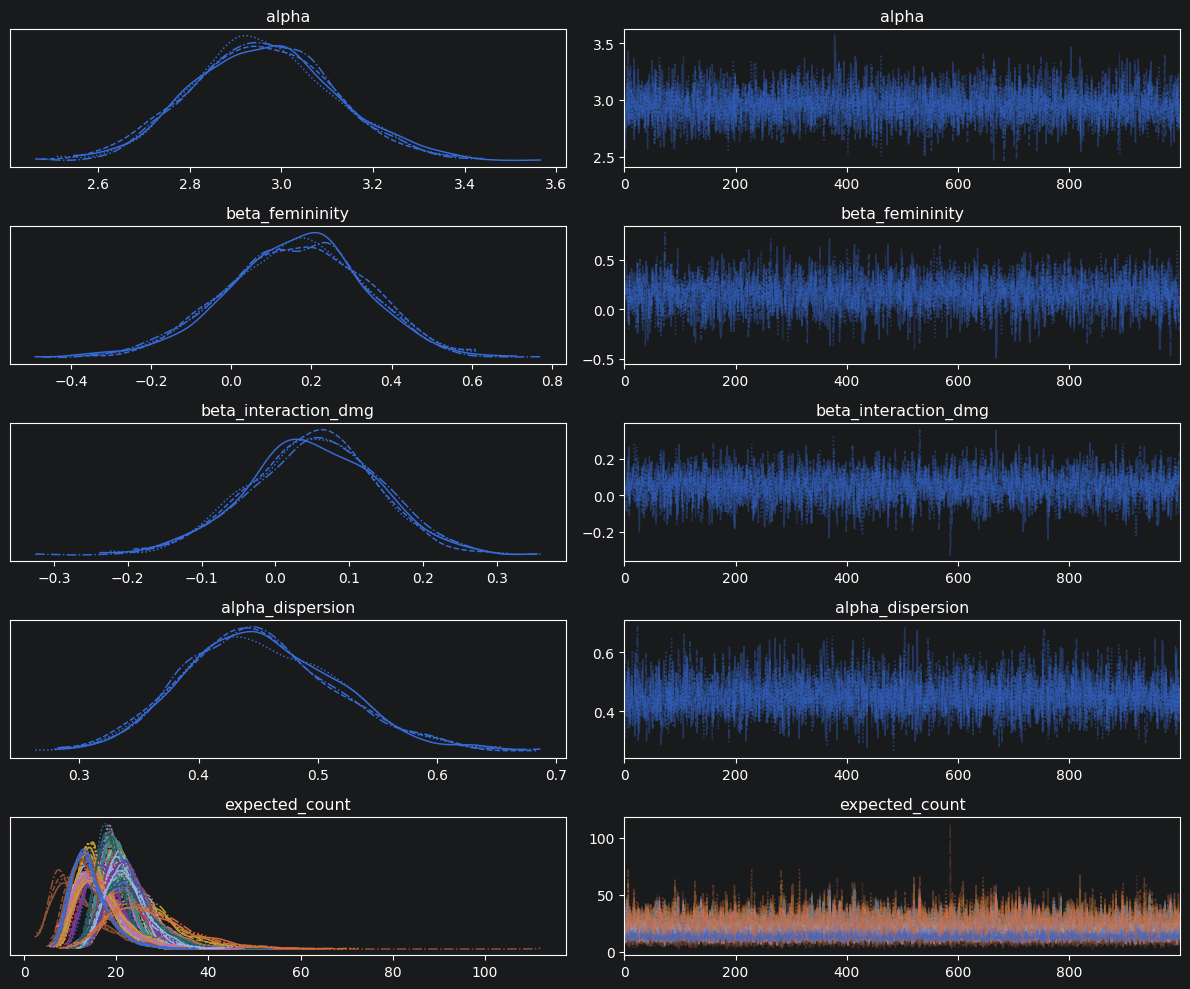

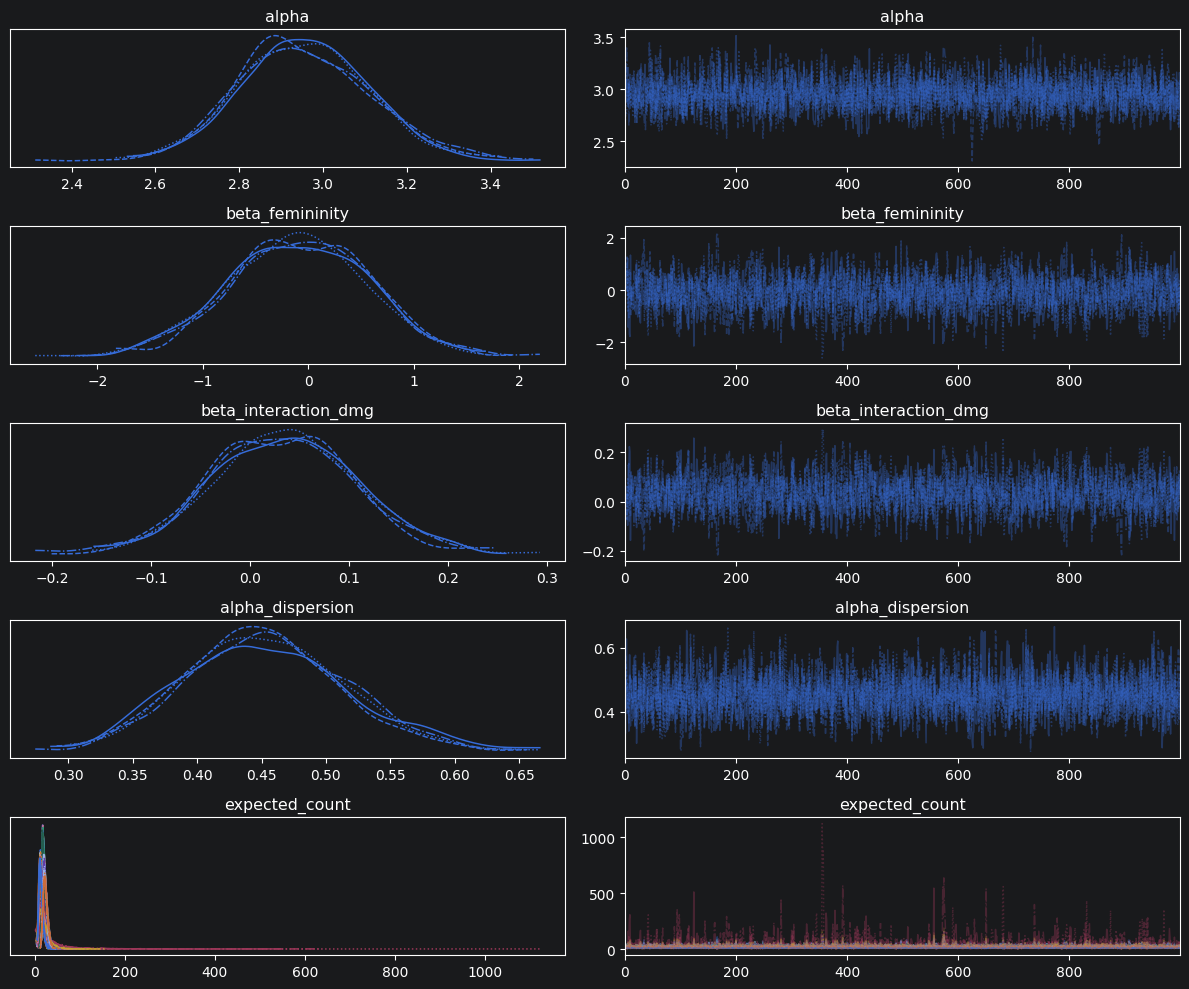

In [8]:
for post in (posterior_dmg, posterior_dmg_log):
    plot_trace(post)

In [9]:
comparison = az.compare({
    "damage": posterior_dmg,
    "damage_log": posterior_dmg_log,
}, scale="deviance", ic="waic")
comparison

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
damage_log,0,711.369084,4.839032,0.00000,1.0,32.872758,0.000000,True,deviance
damage,1,712.560224,5.453700,1.19114,0.0,33.513822,2.479775,True,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_waic (deviance)', ylabel='ranked models'>

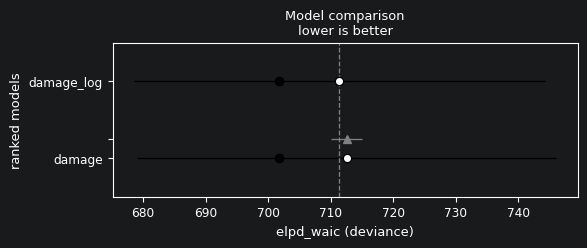

In [10]:
az.plot_compare(comparison, plot_ic_diff=True, insample_dev=True)